In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\kumar\Downloads\Housing.csv")

In [3]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
np.isinf(df['area']).sum()

np.int64(0)

In [6]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


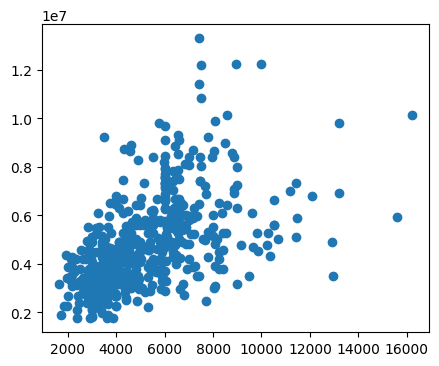

In [7]:
plt.figure(figsize=[5,4])
plt.scatter(df['area'],df['price'])
plt.show()

In [8]:
data=df.copy()

In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['mainroad.1']=le.fit_transform(data['mainroad'])
data['guestroom.1']=le.fit_transform(data['guestroom'])
data['basement.1']=le.fit_transform(data['basement'])
data['hotwaterheating.1']=le.fit_transform(data['hotwaterheating'])
data['airconditioning.1']=le.fit_transform(data['airconditioning'])
data['prefarea.1']=le.fit_transform(data['prefarea'])
data['furnishingstatus.1']=le.fit_transform(data['furnishingstatus'])

In [10]:
data['furnishingstatus'].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [11]:
data.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,mainroad.1,guestroom.1,basement.1,hotwaterheating.1,airconditioning.1,prefarea.1,furnishingstatus.1
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1,0,0,0,1,1,0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1,0,0,0,1,0,0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1,0,1,0,0,1,1
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1,0,1,0,1,1,0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1,1,1,0,1,0,0


# all scatter plot for correlation

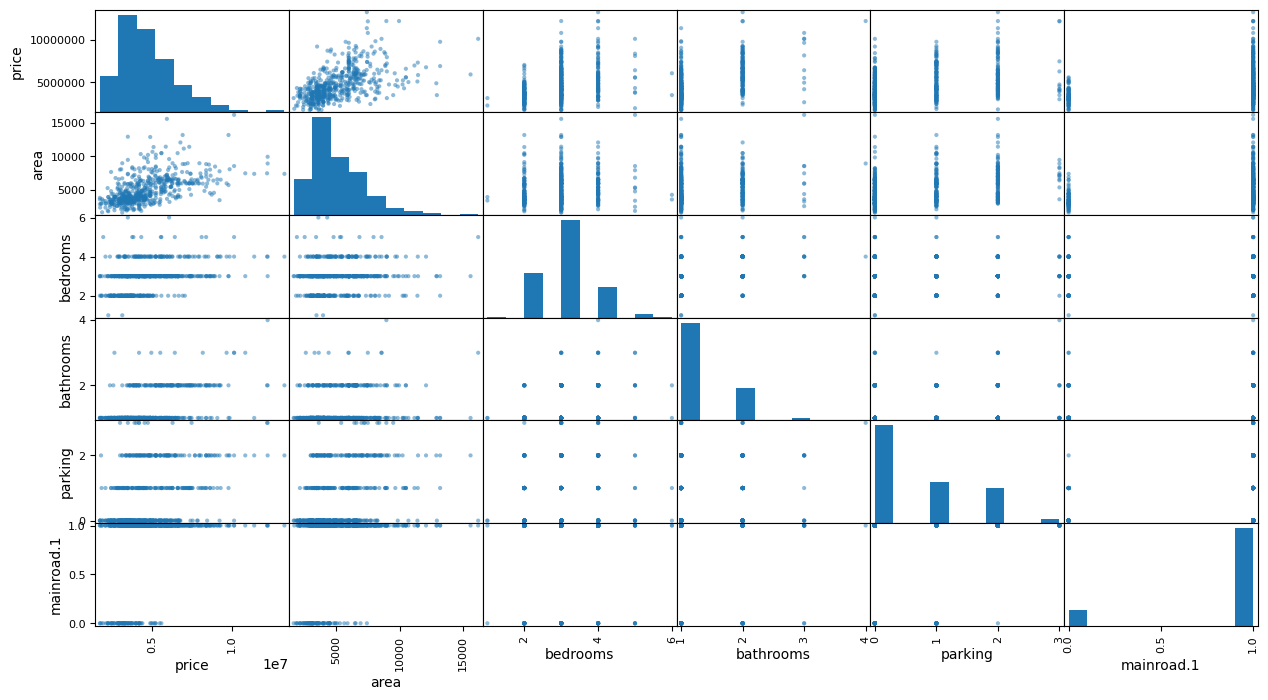

In [12]:
from pandas.plotting import scatter_matrix
attribute=['price','area','bedrooms','bathrooms','parking','mainroad.1']
scatter_matrix(data[attribute],figsize=(15,8))
plt.show()

In [13]:
#plt.figure(figsize=[7,5])
#sns.heatmap(data=data2.corr(),annot=True)
#plt.show()
# it also work if no lable column is present

# correlation

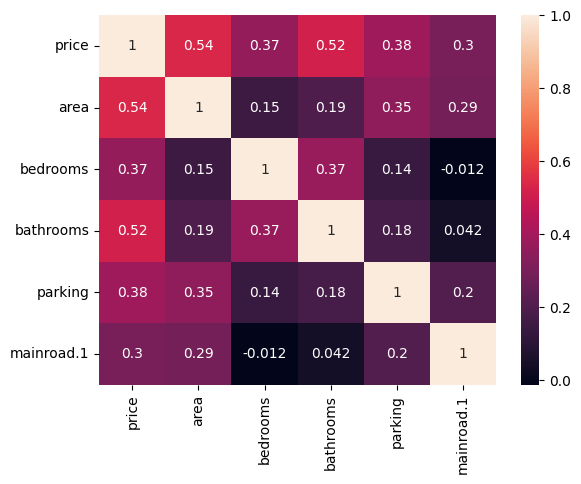

               price      area  bedrooms  bathrooms   parking  mainroad.1
price       1.000000  0.535997  0.366494   0.517545  0.384394    0.296898
area        0.535997  1.000000  0.151858   0.193820  0.352980    0.288874
bedrooms    0.366494  0.151858  1.000000   0.373930  0.139270   -0.012033
bathrooms   0.517545  0.193820  0.373930   1.000000  0.177496    0.042398
parking     0.384394  0.352980  0.139270   0.177496  1.000000    0.204433
mainroad.1  0.296898  0.288874 -0.012033   0.042398  0.204433    1.000000


In [14]:
corr=data[attribute].corr()
x=corr[['price','area','bedrooms','bathrooms','parking','mainroad.1']]
sns.heatmap(x,annot=True)
plt.show()
print(x)

In [15]:
q1=data['price'].quantile(0.25)
q3=data['price'].quantile(0.75)
Q1=data['area'].quantile(0.25)
Q3=data['area'].quantile(0.75)
q1,q3,Q1,Q3

(np.float64(3430000.0),
 np.float64(5740000.0),
 np.float64(3600.0),
 np.float64(6360.0))

In [16]:
iqr=q3-q1
min=q1-(iqr*1.5)
max=q3+(iqr*1.5)
IQR=Q3-Q1
Min=Q1-(IQR*1.5)
Max=Q3+(IQR*1.5)
iqr,min,max,IQR,Max,Min

(np.float64(2310000.0),
 np.float64(-35000.0),
 np.float64(9205000.0),
 np.float64(2760.0),
 np.float64(10500.0),
 np.float64(-540.0))

In [17]:
data1=data[data['price']<max]
data2=data1[data1['area']<Max]

In [18]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler()
data2['area1']=pd.DataFrame(sc.fit_transform(data2[['area']]),columns=['X'])

C:\Users\kumar\AppData\Local\Temp\ipykernel_3344\1001072132.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['area1']=pd.DataFrame(sc.fit_transform(data2[['area']]),columns=['X'])


In [19]:
df.shape,data2.shape

((545, 13), (517, 21))

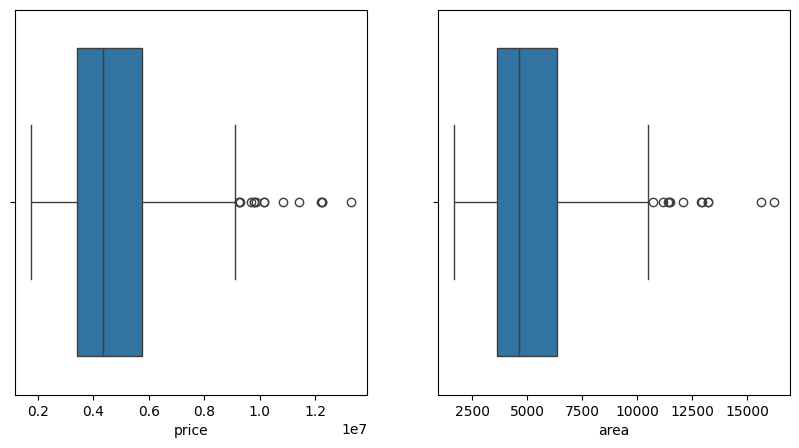

In [20]:
plt.figure(figsize=[10,5])
plt.subplot(1,2,1)
sns.boxplot(x=df['price'])
plt.subplot(1,2,2)
sns.boxplot(x=df['area'])
plt.show()

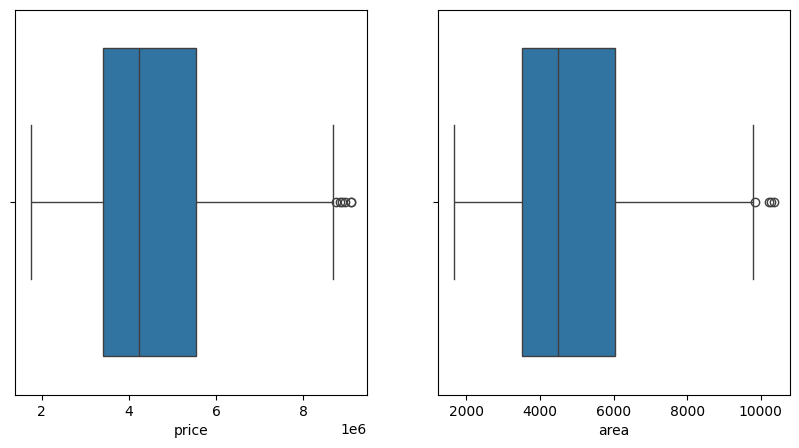

In [21]:

plt.figure(figsize=[10,5])
plt.subplot(1,2,1)
sns.boxplot(x=data2['price'])
plt.subplot(1,2,2)
sns.boxplot(x=data2['area'])
plt.show()

C:\Users\kumar\AppData\Local\Temp\ipykernel_3344\1034132569.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data2['price'])
C:\Users\kumar\AppData\Local\Temp\ipykernel_3344\1034132569.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


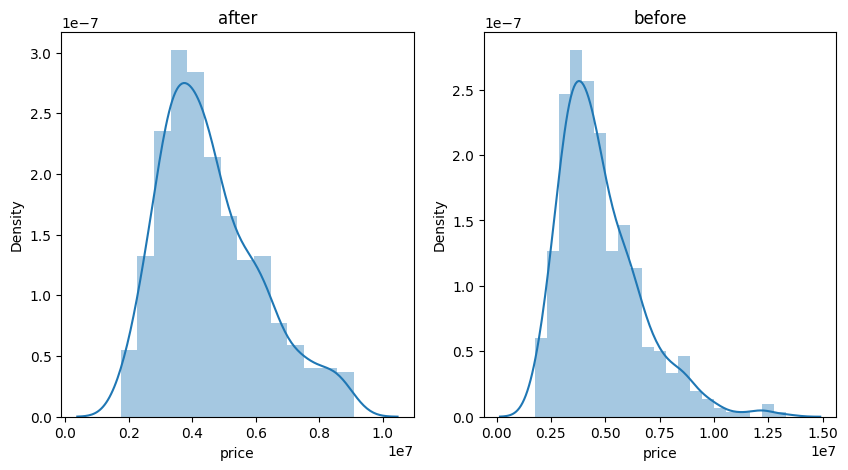

In [22]:
plt.figure(figsize=[10,5])
plt.subplot(1,2,1)
sns.distplot(data2['price'])
plt.title("after")
plt.subplot(1,2,2)
sns.distplot(df['price'])
plt.title("before")
plt.show()

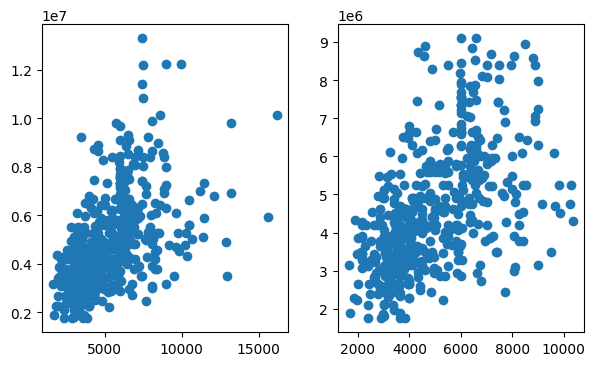

In [23]:
plt.figure(figsize=[7,4])
plt.subplot(1,2,1)
plt.scatter(df['area'],df['price'])
plt.subplot(1,2,2)
plt.scatter(data2['area'],data2['price'])
plt.show()

In [24]:
data2['area1']=data2['area1'].fillna(data2['area1'].mean())

C:\Users\kumar\AppData\Local\Temp\ipykernel_3344\4232976397.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['area1']=data2['area1'].fillna(data2['area1'].mean())


In [25]:
data2.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,...,prefarea,furnishingstatus,mainroad.1,guestroom.1,basement.1,hotwaterheating.1,airconditioning.1,prefarea.1,furnishingstatus.1,area1
15,9100000,6000,4,1,2,yes,no,yes,no,no,...,no,semi-furnished,1,0,1,0,0,0,1,0.668772
16,9100000,6600,4,2,2,yes,yes,yes,no,yes,...,yes,unfurnished,1,1,1,0,1,1,2,0.614237
17,8960000,8500,3,2,4,yes,no,no,no,yes,...,no,furnished,1,0,0,0,1,0,0,0.370838
18,8890000,4600,3,2,2,yes,yes,no,no,yes,...,no,furnished,1,1,0,0,1,0,0,0.494834
19,8855000,6420,3,2,2,yes,no,no,no,yes,...,yes,semi-furnished,1,0,0,0,1,1,1,0.595867


In [26]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking,mainroad.1,guestroom.1,basement.1,hotwaterheating.1,airconditioning.1,prefarea.1,furnishingstatus.1
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578,0.858716,0.177982,0.350459,0.045872,0.315596,0.234862,1.069725
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586,0.348635,0.382849,0.477552,0.209399,0.465180,0.424302,0.761373
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [27]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517 entries, 15 to 544
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               517 non-null    int64  
 1   area                517 non-null    int64  
 2   bedrooms            517 non-null    int64  
 3   bathrooms           517 non-null    int64  
 4   stories             517 non-null    int64  
 5   mainroad            517 non-null    object 
 6   guestroom           517 non-null    object 
 7   basement            517 non-null    object 
 8   hotwaterheating     517 non-null    object 
 9   airconditioning     517 non-null    object 
 10  parking             517 non-null    int64  
 11  prefarea            517 non-null    object 
 12  furnishingstatus    517 non-null    object 
 13  mainroad.1          517 non-null    int64  
 14  guestroom.1         517 non-null    int64  
 15  basement.1          517 non-null    int64  
 16  hotwaterheat

In [28]:
from sklearn.linear_model import Lasso,Ridge

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
X=data2[['area','bedrooms','bathrooms','stories','mainroad.1','guestroom.1','basement.1','hotwaterheating.1','airconditioning.1','prefarea.1','furnishingstatus.1','parking']]
y=data2['price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#lr=DecisionTreeRegressor()
lr=LinearRegression()
#lr=RandomForestRegressor()
lr.fit(X_train,y_train)
predict=lr.predict(X_test)

In [31]:
mse=mean_squared_error(y_test,predict)
mae=mean_absolute_error(y_test,predict)
r2=(r2_score(y_test,predict))*100
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",np.sqrt(mse))
print("r2_score:",r2,)

MSE: 977664860283.9722
MAE: 742678.2862974494
RMSE: 988769.3665784616
r2_score: 66.67603355640938


# LASSO AND RIDGE

In [32]:
la=Lasso(alpha=0.5)
la.fit(X_train,y_train)
la.score(X_test,y_test)*100

66.67603389759637

In [33]:
ra=Ridge(alpha=10)
ra.fit(X_train,y_train)
ra.score(X_test,y_test)


0.665855141440493

# cross validation

In [34]:
from sklearn.model_selection import cross_val_score
cross=cross_val_score(.............)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1548485588.py, line 2)

In [ ]:
X_test

,area,bedrooms,bathrooms,stories,mainroad.1,guestroom.1,basement.1,hotwaterheating.1,airconditioning.1,prefarea.1,furnishingstatus.1,parking
331,7260,3,2,1,1,1,1,0,0,0,0,3
529,3970,3,1,2,1,0,1,0,0,0,2,0
469,4600,2,1,1,1,0,0,0,0,0,0,0
177,6050,3,1,1,1,0,1,0,0,1,1,0
531,5300,3,1,1,0,0,0,0,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
193,4800,2,1,1,1,1,1,0,0,0,1,0
302,2145,3,1,3,1,0,0,0,0,1,2,1
537,1700,3,1,2,1,0,0,0,0,0,2,0
541,2400,3,1,1,0,0,0,0,0,0,1,0


In [ ]:
y_test

331    3920000
529    2275000
469    3010000
177    5243000
531    2233000
        ...   
193    5033000
302    4200000
537    1890000
541    1767150
347    3836000
Name: price, Length: 104, dtype: int64

In [ ]:
result=lr.predict([[1700,3,1,2,1,0,0,0,0,0,2,0]])
result

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([2496060.])